In [1]:
import sys
import os
from os.path import join
import glob
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

sys.path.insert(0, "../../ABC-SN/code")
import abcsn_config
import abcsn_training
import data_degrading as dg
import data_plotting as dplt
import data_preparation as dp
import preprocessing

sys.path.insert(0, "../code")
import review_spectrum as rs
import spectral_features as sf
import measure_signal as ms

from icecream import ic
from importlib import reload

2026-03-15 13:51:54.854508: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
REPO_DIR = "../"
DATA_DIR = join(REPO_DIR, "data")

In [3]:
def unpack_dataset(sn_data):
    df_fluxes = sn_data.filter(regex="\d+")
    fluxes = df_fluxes.to_numpy(dtype=float)

    flux_columns = df_fluxes.columns
    wvl = flux_columns.to_numpy(dtype=float)

    metadata_columns = sn_data.columns.difference(flux_columns)
    df_metadata = sn_data[metadata_columns]

    return wvl, fluxes, df_metadata

In [4]:
file_dataset = "../data/forSNR/final_full_dataset.parquet"
df = pd.read_parquet(file_dataset)
wvl, spectra, df_meta = unpack_dataset(df)
num_spectra = spectra.shape[0]
num_wvl = wvl.shape[0]
wvl.shape, spectra.shape, df_meta.shape

((1024,), (3574, 1024), (3574, 20))

In [5]:
def measure_signal_algorithm(specsnr, options):
    assert options["Denoising Parameter"] != -999
    assert not np.isnan(options["Denoising Parameter"])
    
    if np.isnan(options["minima_i"]):
        options["minima_i"] = None

    specsnr.denoise_gaussian(options["Denoising Parameter"])
    specsnr.find_spectral_line(
        feature_search_bounds=(options["searchBlu"], options["searchRed"]),
        minima_i=options["minima_i"])
    specsnr.find_spectral_shoulders(
        blu_shoulder_nudge=options["maxBlu"].astype(int),
        red_shoulder_nudge=options["maxRed"].astype(int))
    specsnr.calc_pEW()
    specsnr.measure_feature_noise(
        noise_window_blu=options["noiseWindowBlu"],
        noise_window_red=options["noiseWindowRed"],
        useBlu=options["useBlu"],
        useRed=options["useRed"])
    specsnr.measure_SNR()
    return

In [6]:
SNRobjs = np.empty(num_spectra, dtype=object)
for i in tqdm(range(num_spectra)):
    metadata_i = df_meta.loc[i].copy(deep=True)
    spectrum_i = spectra[i]

    specsnr = ms.SpectrumSNR(
        metadata_i["SN Name"],
        metadata_i["SN Subtype"],
        metadata_i["Spectral Phase"],
        wvl,
        spectrum_i)
    specsnr.summarize()
    specsnr.minmax_normalize()
    specsnr.set_spectral_feature()
    
    measure_signal_algorithm(specsnr, metadata_i)
    SNRobjs[i] = specsnr

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3574/3574 [05:01<00:00, 11.84it/s]


In [7]:
def plot_with_SNR_stuff(specsnr, ax=None):
    if ax is None:
        fig, ax = plt.subplots(ncols=1, nrows=1, sharex=True, figsize=(6, 1))    
    ax.set_xlim((4500, 7000))
    ax.axis("off")
    
    # spectrum_diff_mask = detect_flat_sections(specsnr.wvl, specsnr.spectrum)
    # ax.fill_between(wvl, y1=1, y2=0, where=spectrum_diff_mask, alpha=0.5, color="tab:orange")
    
    ax.plot(wvl, specsnr.spectrum, c="k", lw=1)
    ax.plot(wvl, specsnr.signal, c="tab:blue")

    vertical_midpoint = np.sum(ax.get_ylim()) / 2
    horizontal_text_location = ax.get_xlim()[0]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f"{specsnr.name}\n{specsnr.subtype}\n{specsnr.phase} days",
        ha="right", va="center")

    horizontal_text_location = ax.get_xlim()[1]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f"SNR = {specsnr.SNR:.2f}\nS = {specsnr.S:.2e}\nN = {specsnr.N:.2e}\n$\sigma = {specsnr.denoising_parameter}$",
        ha="left", va="center")

    ax.plot(specsnr.pc_wvl, specsnr.pseudo_cont, c="tab:green")

    # Color in the regions used to calculate the noise on the red and blue
    # shoulders.
    if specsnr.useBlu:
        ax.fill_between(
            specsnr.wvl[specsnr.blu_inds],
            y1=1,
            y2=0,
            color="tab:blue",
            alpha=0.25)
        ax.fill_between(
            specsnr.wvl[specsnr.blu_inds],
            y1=1,
            y2=0,
            color="tab:blue",
            alpha=0.25)

    if specsnr.useRed:
        ax.fill_between(
            specsnr.wvl[specsnr.red_inds],
            y1=1,
            y2=0,
            color="tab:red",
            alpha=0.25)
        ax.fill_between(
            specsnr.wvl[specsnr.red_inds],
            y1=1,
            y2=0,
            color="tab:red",
            alpha=0.25)
    return

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 358/358 [02:40<00:00,  2.23it/s]


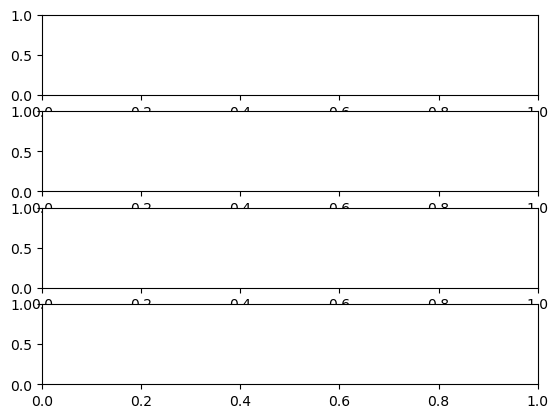

In [9]:
SNRobjs_argsort = np.argsort([specsnr.SNR for specsnr in SNRobjs])
SNRobjs_sorted = SNRobjs[SNRobjs_argsort][::-1]

lines_per_fig = 10

num_spec = len(SNRobjs_sorted)
for i in tqdm(range(0, num_spec, lines_per_fig)):
    if i + lines_per_fig < num_spec:
        pass
    else:
        lines_per_fig = num_spec - i
        fig, axes = plt.subplots(ncols=1, nrows=lines_per_fig)

    fig, axes = plt.subplots(ncols=1, nrows=lines_per_fig, figsize=(6, lines_per_fig))
        
    for j in range(lines_per_fig):
        plot_with_SNR_stuff(SNRobjs_sorted[i+j], axes[j])

    fig.tight_layout()
    fig.savefig(f"../spectra_sparklines_SNRinfo/{i:0>5}")
    plt.close()